In [ ]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Wellness Company Data Analysis Case Study
## How can a Wellness Company Play It Smart?

### 1.0 Introduction

Bellabeat is a high-tech wellness company that develops smart products designed to help women monitor and improve their overall health and lifestyle. By collecting and analyzing health-related data such as physical activity, sleep patterns, stress levels and wellness habits, Bellabeat enables records to gain a deeper understanding of their daily behaviors and make informed decisions toward achieving healthier lifestyles.

Since its establishment in 2013, Bellabeat has grown rapidly and positioned itself as a technology-driven wellness company by combining health insights with elegantly designed smart products. Through products such as wellness trackers, smart watches, hydration trackers and personalized wellness applications, Bellbeat aims to empower women with knowledge and data-driven guidance regarding their health. 

As a Junior Data Analyst working with the Bellabeat marketing analytics team, the purpose of this case study is to analyze smart device fitness data in order to identify trends and patterns in observed behaviors. Understanding how records interact with smart devices can provide valuable insights into their activity habits, sleep behavior and overall engagement with health-tracking technologies. 

## 2.0 Business Task
The main objective of this case study is to analyze device fitness data in order to identify trends and patterns in recorded behaviors. Understanding how observations interact with smart devices can provide insights into their activity levels, sleep habits and overall wellness behavior.

The insights obtained from this analysis will be used to support Bellabeat in making data-driven business decisions and developing effective marketing strategies for its products. By understanding usage records, Bellabeat can better engage its customers and identify opportunities for future growth.

This analysis aims to answer the following business questions:

1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat's marketing strategy?

## 3.0 Stakeholders

The key stakeholders involved in this case study include:

#### Urška Sršen
Bellabeat's co-founder and Chief Creative Officer who believes that analyzing smart device fitness data can help identify growth opportunities and improve business strategies.

#### Sando Mur
Bellabeat's co-founder and a key member of the executive team who is involved in business decision-making and strategic planning.

#### Bellabeat Marketing Analytics Team
The team responsible for collecting, analyzing and interpreting data to support Bellabeat's marketing initiatives and business goals.

#### Bellabeat Customers
Current and potential records of Bellabeat products who may benefit from improved marketing strategies and personalized wellness experiences developed through data-driven insights.

## 4.0 Data Source

The dataset used for this analysis is the Fitbit Fitness Tracker Data obtained from Kaggle. The dataset contains personal fitness tracker information collected from Fitbit records and includes data related to physical activity, daily steps, calories burned, sleep tracking and activity intensity levels.

The dataset consists of fitness tracking information collected from 30 eligible Fitbit records and voluntarily consented to the submission of other personal tracker data. The data includes various health and activity metrics that can be used to understand observed behaviors and identify trends in smart device usage.

For this analysis, the following datasets will be used:

- **dailyActivity_merged.csv**
   - Contains daily activity information including total steps, total distance, calories burned and activity intensity measurements.

- **sleepDay_merged.csv**
   - Contains sleep tracking information including total minutes asleep and total time spent in bed.

- **hourlySteps_merged.csv**
   - Contains hourly step counts to analyze recorded activity patterns throughout the day.

- **hourlyCalories_merged.csv**
   - Contains hourly calories burned data.

- **hourlyIntensities_merged.csv**
   - Contains hourly activity intensity information.


#### Data Credibility (ROCCC Framework)

**Reliable**
- The dataset was collected from Fitbit records and contains real-world activity tracking information.

**Comprehensive**
- The dataset includes multiple health-related variables such as activity, calories and sleep data.

**Current**
- The data was collected in 2026 and may not completely represent current observed behaviors and trends.

**Cited**
- The dataset is publicly available and appropriately licensed for analytical purposes.


Note: The dataset contains several limitations that will be discussed further in Section 13.0 Limitations & Future Improvements.  

# 5.0 Data Cleaning 

Data cleaning is an essential step in the data analysis process, as it ensures that the dataset is accurate, complete and suitable for analysis. Raw datasets often contain duplicate records, inconsistent formatting, missing values and data quality issues that may affect analytical results.

For this case study, R will be used for loading and preparing the datasets. The data cleaning process includes:

- Loading required libraries
- Define data paths
- Importing selected datasets
- Examining dataset structures
- Checking for missing values
- Identifying duplicate records
- Preparing datasets for further analysis

### 5.1 Load Required Libraries

The following libraries will be used for data manipulation, cleaning and date handling throughout this analysis.

In [49]:
library(tidyverse)
library(lubridate)
library(janitor)
library(skimr)

### 5.2 Define Data Path

The data path is defined to organize and access the selected Fitbit datasets used throughout this analysis.

In [50]:
list.files("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16")

[1] "dailyActivity_merged.csv"           "dailyCalories_merged.csv"          
 [3] "dailyIntensities_merged.csv"        "dailySteps_merged.csv"             
 [5] "heartrate_seconds_merged.csv"       "hourlyCalories_merged.csv"         
 [7] "hourlyIntensities_merged.csv"       "hourlySteps_merged.csv"            
 [9] "minuteCaloriesNarrow_merged.csv"    "minuteCaloriesWide_merged.csv"     
[11] "minuteIntensitiesNarrow_merged.csv" "minuteIntensitiesWide_merged.csv"  
[13] "minuteMETsNarrow_merged.csv"        "minuteSleep_merged.csv"            
[15] "minuteStepsNarrow_merged.csv"       "minuteStepsWide_merged.csv"        
[17] "sleepDay_merged.csv"                "weightLogInfo_merged.csv"

In [51]:
# Define dataset path
data_path <- "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/"

### 5.3 Load Files

The selected datasets are imported into R for further cleaning and analysis. These files contain information related to recorded activity, sleep patterns, calories burned and activity intensity. 

In [52]:
# Load selected datasets

daily_activity <- read.csv(
    paste0(data_path, "dailyActivity_merged.csv")
)

sleep_data <- read.csv(
    paste0(data_path, "sleepDay_merged.csv")
)

hourly_steps <- read.csv(
    paste0(data_path, "hourlySteps_merged.csv")
)

hourly_calories <- read.csv(
    paste0(data_path, "hourlyCalories_merged.csv")
)

hourly_intensity <- read.csv(
    paste0(data_path, "hourlyIntensities_merged.csv")
)

### 5.4 Initial Data Inspection

After loading the datasets, an initial inspection is conducted to understand the structure of the data, verify successful imports and identify potential issues before cleaning.

In [53]:
# Display dataset structure

str(daily_activity)
str(sleep_data)
str(hourly_steps)
str(hourly_calories)
str(hourly_intensity)

'data.frame':	940 obs. of  15 variables:
 $ Id                      : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ ActivityDate            : chr  "4/12/2016" "4/13/2016" "4/14/2016" "4/15/2016" ...
 $ TotalSteps              : int  13162 10735 10460 9762 12669 9705 13019 15506 10544 9819 ...
 $ TotalDistance           : num  8.5 6.97 6.74 6.28 8.16 ...
 $ TrackerDistance         : num  8.5 6.97 6.74 6.28 8.16 ...
 $ LoggedActivitiesDistance: num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveDistance      : num  1.88 1.57 2.44 2.14 2.71 ...
 $ ModeratelyActiveDistance: num  0.55 0.69 0.4 1.26 0.41 ...
 $ LightActiveDistance     : num  6.06 4.71 3.91 2.83 5.04 ...
 $ SedentaryActiveDistance : num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveMinutes       : int  25 21 30 29 36 38 42 50 28 19 ...
 $ FairlyActiveMinutes     : int  13 19 11 34 10 20 16 31 12 8 ...
 $ LightlyActiveMinutes    : int  328 217 181 209 221 164 233 264 205 211 ...
 $ SedentaryMinutes        : int  728 776 1218 726 773 539 

In [54]:
# Display summary statistics 

summary(daily_activity)
summary(sleep_data)

       Id            ActivityDate         TotalSteps    TotalDistance   
 Min.   :1.504e+09   Length:940         Min.   :    0   Min.   : 0.000  
 1st Qu.:2.320e+09   Class :character   1st Qu.: 3790   1st Qu.: 2.620  
 Median :4.445e+09   Mode  :character   Median : 7406   Median : 5.245  
 Mean   :4.855e+09                      Mean   : 7638   Mean   : 5.490  
 3rd Qu.:6.962e+09                      3rd Qu.:10727   3rd Qu.: 7.713  
 Max.   :8.878e+09                      Max.   :36019   Max.   :28.030  
 TrackerDistance  LoggedActivitiesDistance VeryActiveDistance
 Min.   : 0.000   Min.   :0.0000           Min.   : 0.000    
 1st Qu.: 2.620   1st Qu.:0.0000           1st Qu.: 0.000    
 Median : 5.245   Median :0.0000           Median : 0.210    
 Mean   : 5.475   Mean   :0.1082           Mean   : 1.503    
 3rd Qu.: 7.710   3rd Qu.:0.0000           3rd Qu.: 2.053    
 Max.   :28.030   Max.   :4.9421           Max.   :21.920    
 ModeratelyActiveDistance LightActiveDistance Sedentary

       Id              SleepDay         TotalSleepRecords TotalMinutesAsleep
 Min.   :1.504e+09   Length:413         Min.   :1.000     Min.   : 58.0     
 1st Qu.:3.977e+09   Class :character   1st Qu.:1.000     1st Qu.:361.0     
 Median :4.703e+09   Mode  :character   Median :1.000     Median :433.0     
 Mean   :5.001e+09                      Mean   :1.119     Mean   :419.5     
 3rd Qu.:6.962e+09                      3rd Qu.:1.000     3rd Qu.:490.0     
 Max.   :8.792e+09                      Max.   :3.000     Max.   :796.0     
 TotalTimeInBed 
 Min.   : 61.0  
 1st Qu.:403.0  
 Median :463.0  
 Mean   :458.6  
 3rd Qu.:526.0  
 Max.   :961.0  

### 5.5 Check Missing Values and Duplicate Records

The datasets are checked for missing values and duplicate records to ensure data quality before proceeding with analysis.

In [55]:
# Missing values

colSums(is.na(daily_activity))
colSums(is.na(sleep_data))

Id             ActivityDate               TotalSteps 
                       0                        0                        0 
           TotalDistance          TrackerDistance LoggedActivitiesDistance 
                       0                        0                        0 
      VeryActiveDistance ModeratelyActiveDistance      LightActiveDistance 
                       0                        0                        0 
 SedentaryActiveDistance        VeryActiveMinutes      FairlyActiveMinutes 
                       0                        0                        0 
    LightlyActiveMinutes         SedentaryMinutes                 Calories 
                       0                        0                        0

Id           SleepDay  TotalSleepRecords TotalMinutesAsleep 
                 0                  0                  0                  0 
    TotalTimeInBed 
                 0

In [56]:
# Duplicate rows

sum(duplicated(daily_activity))
sum(duplicated(sleep_data))

[1] 0

[1] 3

### 5.6 Remove Duplicate Records

The duplicate check identified three duplicate records within the sleep dataset. Duplicate entries may introduce bias and affect analysis results; therefore, they will be removed before proceeding with further analysis.

In [57]:
# Remove duplicate records

sleep_data <- sleep_data %>%
distinct()

# Verify duplicate removal

sum(duplicated(sleep_data))

[1] 0

#### 5.7 Data Cleaning Summary

The initial data inspection indicated that no missing values were present in the selected datasets. Additionally, no duplicate records were identified in the daily activity dataset. However, three duplicate records were detected in the sleep dataset and removed to improve data quality and ensure reliable analysis results.

## 6.0 Data Processing

After cleaning the datasets, the next step is data processing. Data processing involves transforming and organizing the datasets into a format that is easier to analyze. This process helps create additional variables and prepare the data for exploratory analysis and visualization.

The following tasks will be performed:

- Merge relevant datasets
- Convert variables into appropriate formats
- Preview dataset structures
- Create new variables through feature engineering
- Prepare the merged dataset for further analysis and visualization

### 6.1 Merge Relevant Datasets

The activity and sleep datasets prepared and merged to create a combined dataset. Before merging, date variables are converted into consistent formats to ensure that both datasets used matching date structures. This process allows relationships between activity and sleep observations to be analyzed more effectively. 

In [58]:
# Check raw values again
head(daily_activity$ActivityDate)
head(sleep_data$SleepDay)

class(daily_activity$ActivityDate)

[1] "4/12/2016" "4/13/2016" "4/14/2016" "4/15/2016" "4/16/2016" "4/17/2016"

[1] "4/12/2016 12:00:00 AM" "4/13/2016 12:00:00 AM" "4/15/2016 12:00:00 AM"
[4] "4/16/2016 12:00:00 AM" "4/17/2016 12:00:00 AM" "4/19/2016 12:00:00 AM"

[1] "character"

In [59]:
library(lubridate)

# Convert ActivityDate correctly

daily_activity$ActivityDate <- as.Date(
    daily_activity$ActivityDate,
    format="%m/%d/%Y"
)

# Convert SleepDay correctly

sleep_data$SleepDay <- mdy_hms(
    sleep_data$SleepDay
)

# Extract date only 

sleep_data$SleepDate <- as.Date(
    sleep_data$SleepDay
)

# Merge datasets

combined_data <- merge(
    daily_activity,
    sleep_data,
    by.x = c("Id","ActivityDate"),
    by.y = c("Id","SleepDate")
)

### 6.2 Preview Dataset

The merged dataset is reviewed to understand its structure, verify successful processing and identify potential issues before continuing with analysis.

In [60]:
# Preview dataset

head(combined_data)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
,<dbl>,<date>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dttm>,<int>,<int>,<int>
1,1503960366,2016-04-12,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,2016-04-12,1,327,346
2,1503960366,2016-04-13,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,2016-04-13,2,384,407
3,1503960366,2016-04-15,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,2016-04-15,1,412,442
4,1503960366,2016-04-16,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,2016-04-16,2,340,367
5,1503960366,2016-04-17,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728,2016-04-17,1,700,712
6,1503960366,2016-04-19,15506,9.88,9.88,0,3.53,1.32,5.03,0,50,31,264,775,2035,2016-04-19,1,304,320


In [61]:
#Display structure

str(combined_data)

'data.frame':	410 obs. of  19 variables:
 $ Id                      : num  1.5e+09 1.5e+09 1.5e+09 1.5e+09 1.5e+09 ...
 $ ActivityDate            : Date, format: "2016-04-12" "2016-04-13" ...
 $ TotalSteps              : int  13162 10735 9762 12669 9705 15506 10544 9819 14371 10039 ...
 $ TotalDistance           : num  8.5 6.97 6.28 8.16 6.48 ...
 $ TrackerDistance         : num  8.5 6.97 6.28 8.16 6.48 ...
 $ LoggedActivitiesDistance: num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveDistance      : num  1.88 1.57 2.14 2.71 3.19 ...
 $ ModeratelyActiveDistance: num  0.55 0.69 1.26 0.41 0.78 ...
 $ LightActiveDistance     : num  6.06 4.71 2.83 5.04 2.51 ...
 $ SedentaryActiveDistance : num  0 0 0 0 0 0 0 0 0 0 ...
 $ VeryActiveMinutes       : int  25 21 29 36 38 50 28 19 41 39 ...
 $ FairlyActiveMinutes     : int  13 19 34 10 20 31 12 8 21 5 ...
 $ LightlyActiveMinutes    : int  328 217 209 221 164 264 205 211 262 238 ...
 $ SedentaryMinutes        : int  728 776 726 773 539 775 818 838 732 70

In [62]:
# Display summary statistics

summary(combined_data)

       Id             ActivityDate          TotalSteps    TotalDistance   
 Min.   :1.504e+09   Min.   :2016-04-12   Min.   :   17   Min.   : 0.010  
 1st Qu.:3.977e+09   1st Qu.:2016-04-19   1st Qu.: 5189   1st Qu.: 3.592  
 Median :4.703e+09   Median :2016-04-27   Median : 8913   Median : 6.270  
 Mean   :4.995e+09   Mean   :2016-04-26   Mean   : 8515   Mean   : 6.012  
 3rd Qu.:6.962e+09   3rd Qu.:2016-05-04   3rd Qu.:11370   3rd Qu.: 8.005  
 Max.   :8.792e+09   Max.   :2016-05-12   Max.   :22770   Max.   :17.540  
 TrackerDistance  LoggedActivitiesDistance VeryActiveDistance
 Min.   : 0.010   Min.   :0.0000           Min.   : 0.000    
 1st Qu.: 3.592   1st Qu.:0.0000           1st Qu.: 0.000    
 Median : 6.270   Median :0.0000           Median : 0.570    
 Mean   : 6.007   Mean   :0.1089           Mean   : 1.446    
 3rd Qu.: 7.950   3rd Qu.:0.0000           3rd Qu.: 2.360    
 Max.   :17.540   Max.   :4.0817           Max.   :12.540    
 ModeratelyActiveDistance LightActiveDist

#### 6.3 Feature Engineering

Feature engineering is performed to create new variables that may provide additional insights during analysis. These variables help identify behavioral patterns and trends across dataset observations.

In [63]:
library(dplyr)

# Create weekday column

combined_data$Weekday <- weekdays(
    combined_data$ActivityDate
)

# Convert sleep minutes to hours

combined_data$SleepHours <- (
    combined_data$TotalMinutesAsleep / 60
)

# Create activity level categories

combined_data$ActivityLevel <- case_when(
    combined_data$TotalSteps < 5000 ~ "Sedentary",

    combined_data$TotalSteps >= 5000 &
    combined_data$TotalSteps < 7500 ~ "Low Active",

    combined_data$TotalSteps >= 7500 &
    combined_data$TotalSteps < 10000 ~ "Moderately Active",

    combined_data$TotalSteps >= 10000 ~ "Active"
)

combined_data$ActivityLevel <- factor(
    combined_data$ActivityLevel,
    levels = c(
        "Sedentary",
        "Low Active",
        "Moderately Active",
        "Active"
    )
)

### 6.4 Verify Newly Created Variables

The newly created variables are checked to ensure they have been successfully generated and are suitable for further analysis.

In [64]:
# Verify new variables

head(
    combined_data[
        c(
            "Weekday",
            "SleepHours",
            "ActivityLevel"
        )
    ]
)

,Weekday,SleepHours,ActivityLevel
,<chr>,<dbl>,<fct>
1,Tuesday,5.450000,Active
2,Wednesday,6.400000,Active
3,Friday,6.866667,Moderately Active
4,Saturday,5.666667,Active
5,Sunday,11.666667,Moderately Active
6,Tuesday,5.066667,Active


### 6.5 Data Processing Summary

The datasets were successfully transformed and prepared for analysis. Data variables were standardized, relevant datasets were merged and new variables such as weekday, sleep duration in hours and activity categories were created. These transformations produced a structured dataset that supports exploratory analysis, visualization and dashboard development.

## 7.0 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to identify patterns and relationships within Fitbit records. The analysis focuses on recorded activity levels, sleep behavior, calorie expenditure and daily activity trends to better understand user wellness habits.

The objective of this analysis is to uncover actionable insights that may help Bellabeat importance engagement and create more personalized wellness strategies.

### 7.1 Summary statistics

Summary statistics were generated to understand the overall distribution of activity, sleep and calorie metrics among records.

In [65]:
summary(
    combined_data[
        c(
            "TotalSteps",
            "Calories",
            "SleepHours",
            "VeryActiveMinutes",
            "SedentaryMinutes"
        )
    ]
)

   TotalSteps       Calories      SleepHours      VeryActiveMinutes
 Min.   :   17   Min.   : 257   Min.   : 0.9667   Min.   :  0.00   
 1st Qu.: 5189   1st Qu.:1841   1st Qu.: 6.0167   1st Qu.:  0.00   
 Median : 8913   Median :2207   Median : 7.2083   Median :  9.00   
 Mean   : 8515   Mean   :2389   Mean   : 6.9862   Mean   : 25.05   
 3rd Qu.:11370   3rd Qu.:2920   3rd Qu.: 8.1667   3rd Qu.: 38.00   
 Max.   :22770   Max.   :4900   Max.   :13.2667   Max.   :210.00   
 SedentaryMinutes
 Min.   :   0.0  
 1st Qu.: 631.2  
 Median : 717.0  
 Mean   : 712.1  
 3rd Qu.: 782.8  
 Max.   :1265.0  

#### Interpretation

The summary statistics reveal important patterns in wellness behaviors. Daily step counts range from extremely low activity to over 22,000 steps, with a median of about 8,900, showing that most records achieve moderate activity but with wide variation. Calorie expenditure follows a similar trend, with typical values around 2,200 calories per day, though some records burn far more, reflecting differences in lifestyle intensity. Sleep bahavior is generally close to recommended levels, with a median of just over seven hours, but the spread from under one hour to more than thirteen highlights inconsistent sleep habits among certain records. Very active minutes are limited for most participants, with half recording fewer than ten minutes daily, while a smaller group engages in extended workouts that raise the average. Sedentary time is consistently high, with a median of about twelve hours per day, underscoring a significant wellness challenge. Taken together, these statistics suggest that while records maintain moderate activity and adequate sleep on average, there is a clear need to reduce sedentary, more balanced lifestyles.

### 7.2 Average Daily Activity Metrics 

Average values were calculated to understand typical observations across important wellness indicators.

In [66]:
combined_data %>%
summarise(


    AverageSteps = mean(
        TotalSteps,
        na.rm = TRUE
    ),

    AverageCalories = mean(
        Calories,
        na.rm = TRUE
    ),

    AverageSleepHours = mean(
        SleepHours,
        na.rm = TRUE
    ),

    AverageSedentaryMinutes = mean(
        SedentaryMinutes,
        na.rm = TRUE
    )
)

AverageSteps,AverageCalories,AverageSleepHours,AverageSedentaryMinutes
<dbl>,<dbl>,<dbl>,<dbl>
8514.91,2389.295,6.98622,712.1


#### Interpretation

The average daily metrics provide a clear picture of typical records across key wellness indicators. On average, observations take about 8,515 steps per day, which is close to the commonly recommended 10,000 steps but still slightly below, suggesting room for improvement in daily movement. Calorie expenditure averages around 2,389 calories, reflecting a generally moderate level of activity and energy use. Sleep duration averages just under seven hours per night, aligning fairly well with recommended guidelines, though it indicates that many records may not consistently reach the optimal 7-8 hours of rest. Sedentary time is notably high, averaging 712 minutes per day, which translates to nearly 12 hours of inactivity. This highlights a significant wellness challenge, as prolonged sedentary behavior can offset the benefits of moderate activity and adequate sleep. Overall, these averages suggest that while observations maintain a reasonable balance of activity and rest, reducing sedentary time and slightly increasing daily steps could lead to healthier, more sustainable lifestyle patterns.

### 7.3 Activity Level Distribution

The distribution of records across activity categories was examined to understand overall engagement levels.

In [67]:
combined_data %>%
count(ActivityLevel)

ActivityLevel,n
<fct>,<int>
Sedentary,96
Low Active,72
Moderately Active,77
Active,165


#### Interpretation

The distribution of records across activity categories highlights varying levels of engagement with physical activity. The largest group falls into the **Active** category, with 165 observations, showing that a significant portion of records consistently maintain high activity levels. However, there are also notable segments in the **Sedentary** group (96 records) and the **Low Active** group (72 records), which together represent a substantial proportion of the population who engage in minimal daily movement. The **Moderately Active** group, with 77 observations, reflects those who achieve a balance between sedentary and active lifestyles but may not consistently reach optimal activity thresholds. Overall, this distribution suggests that while many records are highly engaged, a considerable number remain inactive or only lightly active, pointing to opportunities for targeted interventions that encourage sedentary and low-active observations to gradually increase their activity levels and move toward healthier, more sustainable routines. 

### 7.4 Daily Activity Trends by Weekday

Recorded activity patterns across weekdays were analyzed to identify whether observations tend to be more active on specific days. 

In [69]:
combined_data %>%

group_by(Weekday) %>%

summarise(

    AverageSteps = mean(
        TotalSteps,
        na.rm = TRUE
    )
)

Weekday,AverageSteps
<chr>,<dbl>
Friday,7901.404
Monday,9273.217
Saturday,9871.123
Sunday,7297.855
Thursday,8183.516
Tuesday,9182.692
Wednesday,8022.864


#### Interpretation 

The weekday analysis reveals clear differences in recorded activity patterns across the week. The highest average step occur on **Saturday** (9,871 steps) and **Monday** (9,273 steps), suggesting that observations tend to be more active at the start of the week and during weekends, possibly due to leisure activities or structured routines. **Tuesday** also shows relatively high engagement with an average of 9,183 steps, reinforcing early-week activity. In contrast, **Sunday** records the lowest average at just 7,298 steps, indicating that many records may rest or engage in fewer structured activities on that day. Midweek days such as **Wednesday** (8,023 steps) and **Thursday** (8,184 steps) show moderate levels of activity, while **Friday** dips slightly lower at 7,901 steps, perhaps reflecting fatigue or reduced motivation before the weekend. Overall, the trend suggests that observations are most active during weekends and early in the week, highlighting opportunities to encourage consistent movement during mid-week and late-week periods.

### 7.5 Relationship Between Sleep and Activity

The realationship between sleep duration and physical activity was explored to determine whether more active records tend to sleep longer.

In [70]:
cor(
    combined_data$TotalSteps,
    combined_data$SleepHours,
    use = "complete.obs"
)

[1] -0.1903439

#### Interpretation

The correlation results of -0.19 indicates a weak negative relationship between sleep duration and physical activity. In practical terms, this suggests that records who record higher step counts tend to sleep slightly fewer hours, while those with lower activity levels may sleep a bit longer. However, because the correlation is relatively small, the relationship is not strong enough to imply a consistent or direct trade-off between activity and sleep. Instead, it highlights that while there may be a tendency for more active observations to sacrifice some sleep, other factors such as lifestyle, stress or scheduling likely play a larger role in shaping sleep behavior. Overall, the analysis shows that activity and sleep are not strongly linked in this dataset, pointing to the importance of addressing both habits independently when designing wellness strategies. 

## 8.0 Visualizations

Visualizations were created to identify patterns and relationships within Fitbit activity and sleep data. These visual insights help reveal user behaviors and support the development of data-driven recommendations for Bellabeat.

### 8.1 Distribution of Activity Levels

The chart below visualizes the distribution of observations across activity categories.

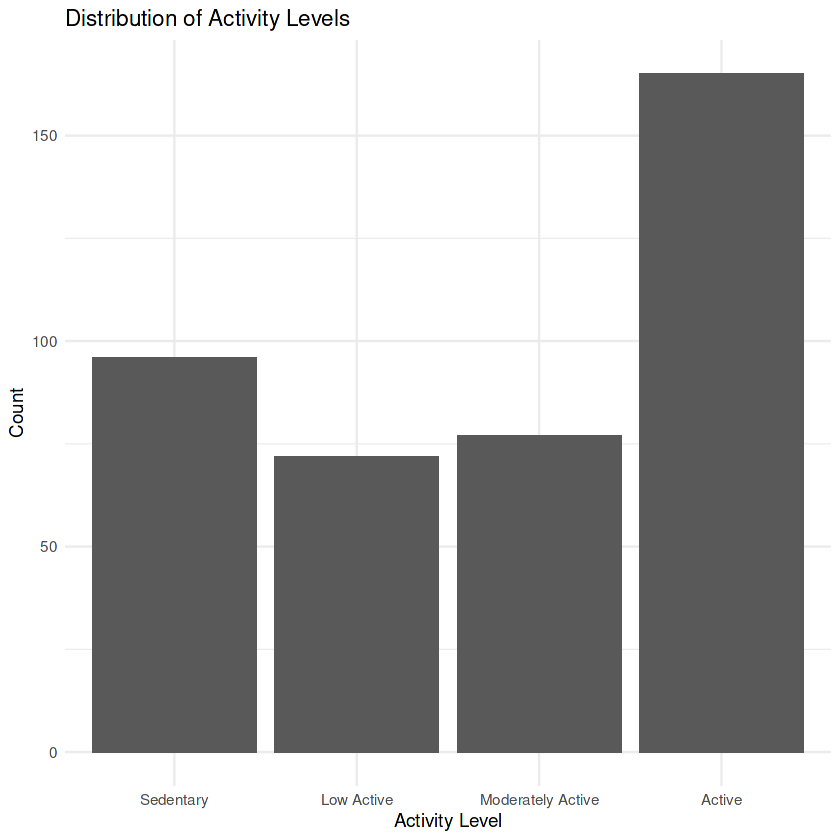

In [71]:
library(ggplot2)

ggplot(
    combined_data,
    aes(x = ActivityLevel)
) +

geom_bar() +

labs(
    title = "Distribution of Activity Levels",
    x = "Activity Level",
    y = "Count"
) +
theme_minimal()

#### Interpretation

The visualization of activity levels shows clear differences in engagement patterns across the dataset. The **Active** category has the highest count, with over 160 records, indicating that a substantial portion of the observations consistently maintain high levels of physical activity. In contrast, the **Sedentary** group, with close to 100 records, represents a significant segment that engages in minimal movement, highlighting a potential wellness concern. The **Low Active** and **Moderately Active** categories, each with around 70-80 observations, suggests that a considerable proportion of the dataset falls into mid-range activity levels, neither fully sedentary nor highly active.

Overall, the chart emphasizes that while any records demonstrate strong activity engagement, there remains a notable share of observations with limited activity. This distribution points to opportunities for targeted strategies aimed at encouraging sedentary and low-active records to gradually increase thier activity, thereby promoting more balanced and sustainable wellness behaviors across the dataset.

### 8.2 Average Daily Steps by Weekday

The visualization examines whether observed activity varies throughout the week.

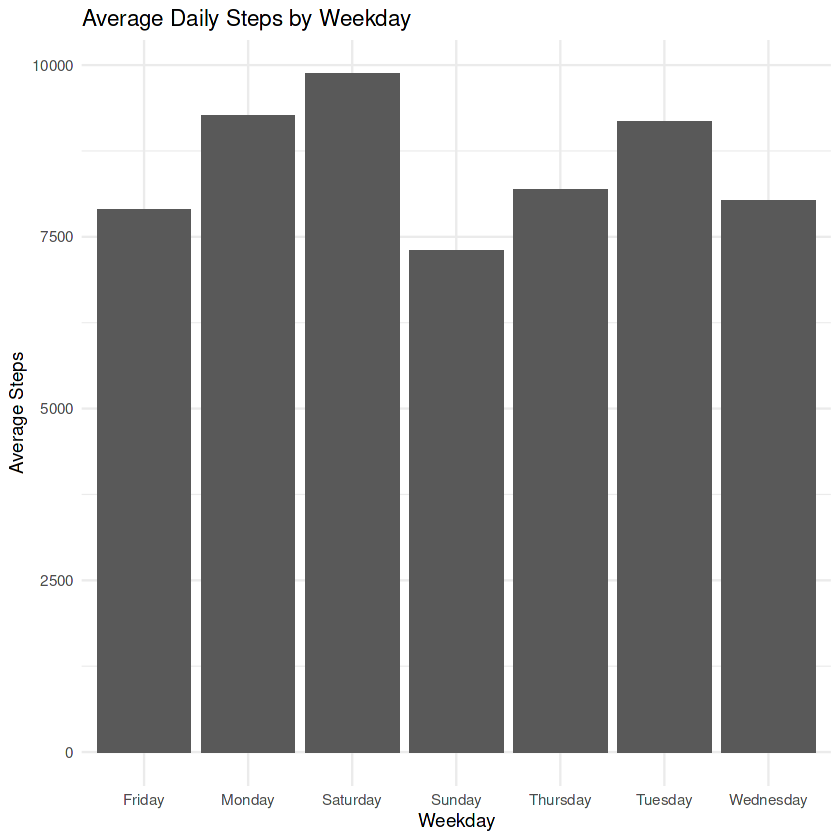

In [72]:
weekday_steps <- combined_data %>%

group_by(Weekday) %>%

summarise(
    AverageSteps = mean(
        TotalSteps,
        na.rm = TRUE
    )
)

ggplot(
    weekday_steps,
    aes(
        x = Weekday,
        y = AverageSteps
    )
) +

geom_col() +

labs(
    title = "Average Daily Steps by Weekday",
    x = "Weekday",
    y = "Average Steps"
) +
theme_minimal()

#### Interpretation

The visualization of average daily steps by weekday highlights distinct activity patterns across the dataset. **Saturday** shows the highest average, slightly above 10,000 steps, suggesting that many observations engage in more movement during weekends, likely due to leisure activities or free time. **Monday** and **Tuesday** also record relatively high averages, both above 9,000 steps, indicating strong activity levels at the start of the week. 

In contrast, **Sunday** reflects the lowest average, around 7,000 steps, which may point to rest days or reduced structures activity. Mid-week days such as **Wednesday** and **Thursday** show moderate averages (around 8,000 steps), while **Friday** dips slightly lower, close to 7,900 steps, possibly reflecting fatigue or reduced motivation before the weekend. 

Overall, the chart suggests that activity peaks during weekends and early in the week, while it declines toward the end of the week. This pattern highlights opportunities to encourage more consistent movement during mid-week and late-week periods, ensuring that all records maintain healthier and more balanced activity levels throughout the week.

### 8.3 Relationship Between Steps and Calories Burned

This visualization explores whether higher activity levels contribute to greater calorie expenditure.

`geom_smooth()` using formula = 'y ~ x'


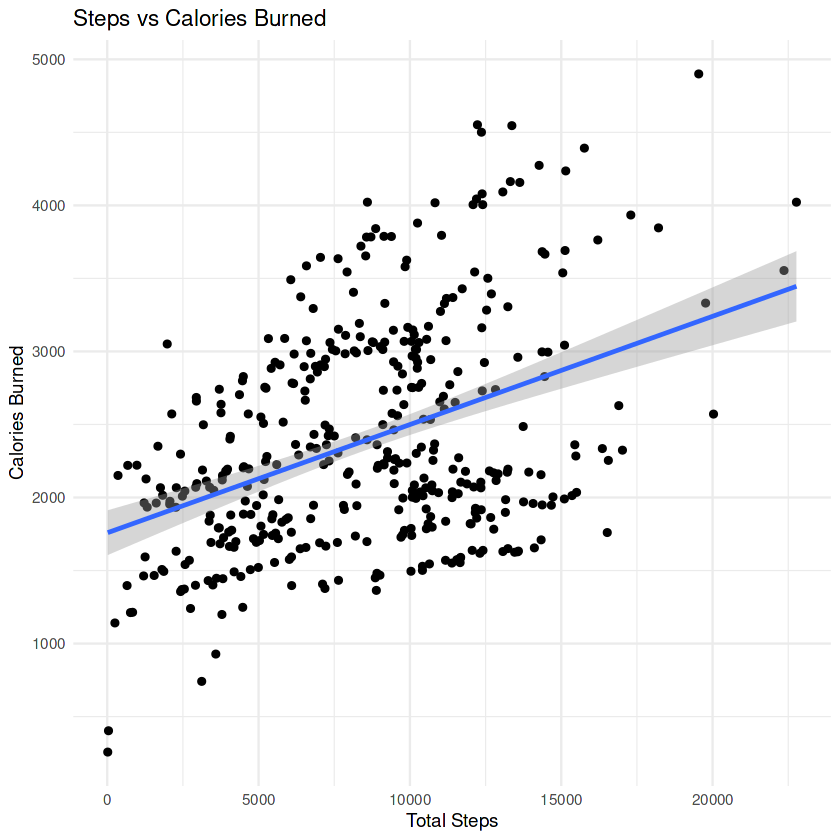

In [73]:
ggplot(
    combined_data,
    aes(
        x = TotalSteps,
        y = Calories
    )
) +

geom_point() +

geom_smooth(
    method = "lm"
) +

labs(
    title = "Steps vs Calories Burned",
    x = "Total Steps",
    y = "Calories Burned"
) +
theme_minimal()

#### Interpretation

The scatter plot illustrates a clear positive relationship between total steps and calories burned. Each point represents an individual observation and the upward-sloping regression line confirms that higher step counts are generally associated with greater energy expenditure. This indicates that more physically active records consistently burn more calories, reinforcing the direct link between movement and energy use.

The confidence interval around the regression line suggests that while the overall trend is strong, there is some variability among observations. For example, certain records may burn more or fewer calories than expected at a given step count, likely due to differences in factors such as body composition,intensity of movement or metabolic rate.

Overall, the visualization highlights that step count is a reliable predictor of calorie expenditure across the dataset. This insight supports the importance of encouraging higher daily step counts as a practical way to increase energy burn and promote healthier activity patterns among observations.

### 8.4 Relationship Between Sleep Duration and Steps

The visualization examines whether activity levels influence sleep duration.

`geom_smooth()` using formula = 'y ~ x'


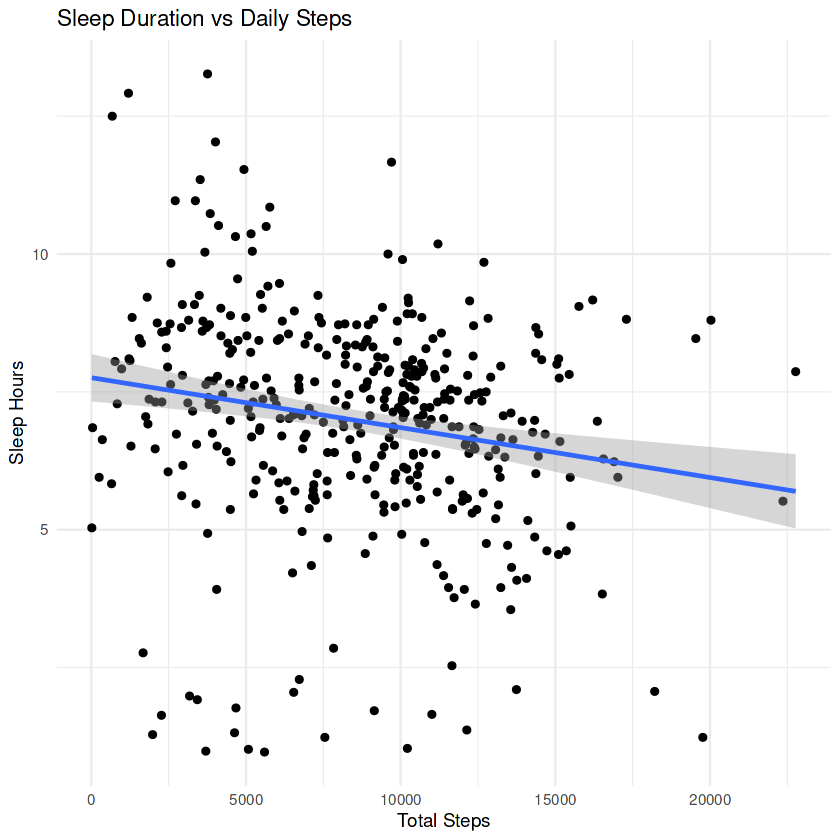

In [74]:
ggplot(
    combined_data,
    aes(
        x = TotalSteps,
        y = SleepHours
    )
) +

geom_point() +

geom_smooth(
    method = "lm"
) +

labs(
    title = "Sleep Duration vs Daily Steps",
    x = "Total Steps",
    y = "Sleep Hours"
) +
theme_minimal()

#### Interpretation

The scatter plot reveals a slight negative relationship between daily step counts and sleep duration. Each point represents an individual observation and the regression line indicates that as total steps increase,sleep hours tend to decrease marginally. This suggests that more active records may be sacrificing a small amount of rest, while less active observations appear to sleep slightly longer. 

However, the correlation is weak, as shown by the wide confidence interval around the regression line. This variability implies that other factors, such as, lifestyle, stress or scheduling, likely play a more significant role in shaping sleep patterns than step count alone.

Overall, the visualization highlights that while activity and sleep are connected, the relationship is not strong enough to suggest a direct trade-off. Instead, both habits should be addressed independently when designing wellness strategies, ensuring that records maintain adequate rest alongside healthy levels of physical activity. 

### 8.5 Sedentary Minutes Distribution

This chart evaluates the level of inactivity across observations.

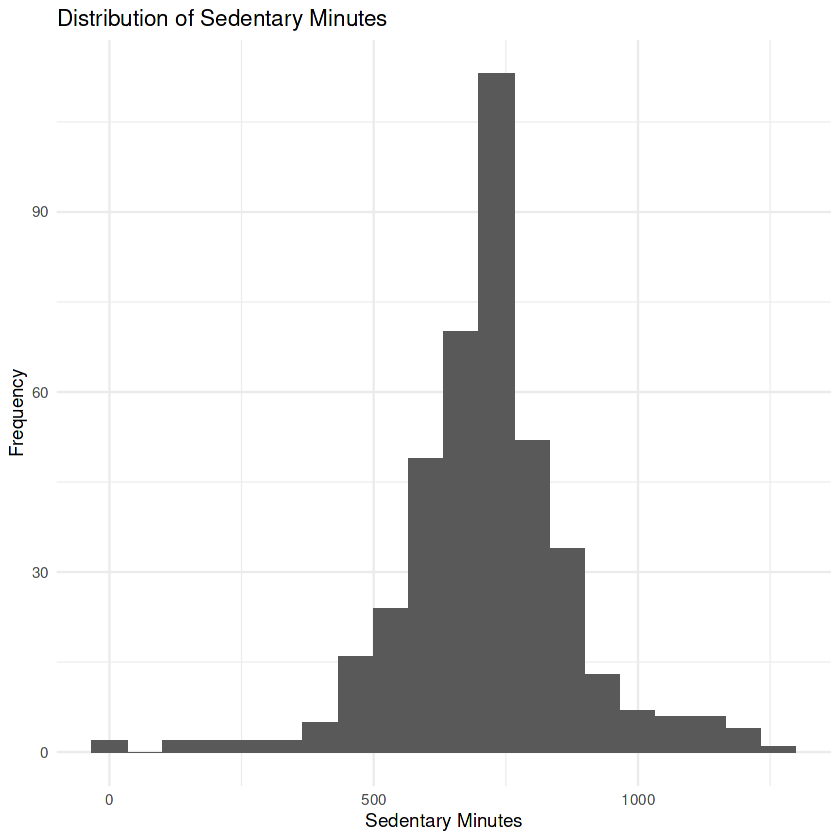

In [75]:
ggplot(
    combined_data,
    aes(
        x = SedentaryMinutes
    )
) +

geom_histogram(
    bins = 20
) +

labs(
    title = "Distribution of Sedentary Minutes",
    x = "Sedentary Minutes",
    y = "Frequency"
) +
theme_minimal()

#### Interpretation

The histogram of sedentary minutes reveals how inactivity is distributed across the dataset. Most observations cluster around the center, with sedentary time averaging approximately 712 minutes per day (roughly 11.9 hours) .This indicates that a large portion of records spend a significant part of the day inactive, which may reflect desk-based work, commuting or leisure activities involving prolonged sitting.

At the extremes, fewer observations record very low or very high sedentary minutes, suggesting that only a small proportion of the dataset maintains highly active routines or experiences prolonged inactivity beyond 14 hours. The distribution highlights that moderate to high sedentary behavior is common, while excessive inactivity remains a wellness concern.

Overall, the visualization emphasizes that reducing sedentary time represents an important opportunity for improvement. Encouraging individuals to break up long periods of inactivity with short bouts of movement could help balance daily activity levels and support healthier lifestyle behaviors across the dataset.

### 9.0 Tableau Dashboard 

A Tableau dashboard was developed to provide an interactive overview of activity, sleep and wellness patterns within the Fitbit dataset. The processed dataset was exported from R and imported into Tableau Desktop for dashboard development. The dashboard integrates multiple visualizations into a single interface, enabling trends and relationships to be explored efficiently. Interactive filters allow specific subsets of the dataset to be examined dynamically and support data-driven decision making.

#### Dataset Export for Tableau

Before creating the dashboard, the processed dataset was exported as a CSV file from R to allow integration with Tableau Desktop.

In [76]:
# Export cleaned dataset for Tableau 

write.csv(
    combined_data,
    "combined_data.csv",
    row.names = FALSE
)

# Verify working directory 

getwd()

# Verify exported files

list.files("/kaggle/working")

[1] "/kaggle/working"

[1] "combined_data.csv"

The exported dataset (`combined_data.csv`) was used as the data source for Tableau dashboard creation.

### 9.1 Dashboard Components 
The Tableau dashboard includes the following components:

#### 1. Activity Level Distribution
Displays the frequency of observations across activity categories to identify overall activity patterns.

#### 2. Average Daily Steps by Weekday
Shows variation in average step counts across different days of the week.

#### 3. Steps vs Calories Burned
Illustrates the relationship between total steps and calorie expenditure. 

#### 4. Sleep Duration vs Daily Steps
Displays the relationship between sleep duration and physical activity.

#### 5. Sedentary Minutes Distribution
Highlights inactivity patterns across observations.

#### 6. Interactive Dashboard Filters

The dashboard includes filters for:

- Weekday
- Activity Level
- Sleep Hours
- Total Steps

These filters allow different subsets of the data to be explored dynamically.

### 9.2 Dashboard Interpretation

The Tableau dashboard provides a consolidated view of wellness patterns within the Fitbit dataset. Activity level patterns indicate that many observations maintain relatively high movement levels, although a considerable proportion remain sedentary or only lightly active.

Daily movement trends demonstrate that activity tends to increase during weekends and early weekdays, while lower activity levels appear on selected days such as Sunday and Friday. 

The relationship between total steps and calories burned shows a clear positive trend, suggesting that greater movement generally corresponds with higher energy expenditure. In contrast, the relationship between sleep duration and daily steps appears relatively weak, indicating that physical activity alone may not strongly influence sleeping patterns.

Sedentary behavior remains an important finding, as many observations record prolonged periods of inactivity throughout the day. Overall, the dashboard provides a comprehensive overview of activity and wellness behavior and supports the development of recommendations for Bellabeat products and services. 

### 9.3 Dashboard Screenshot

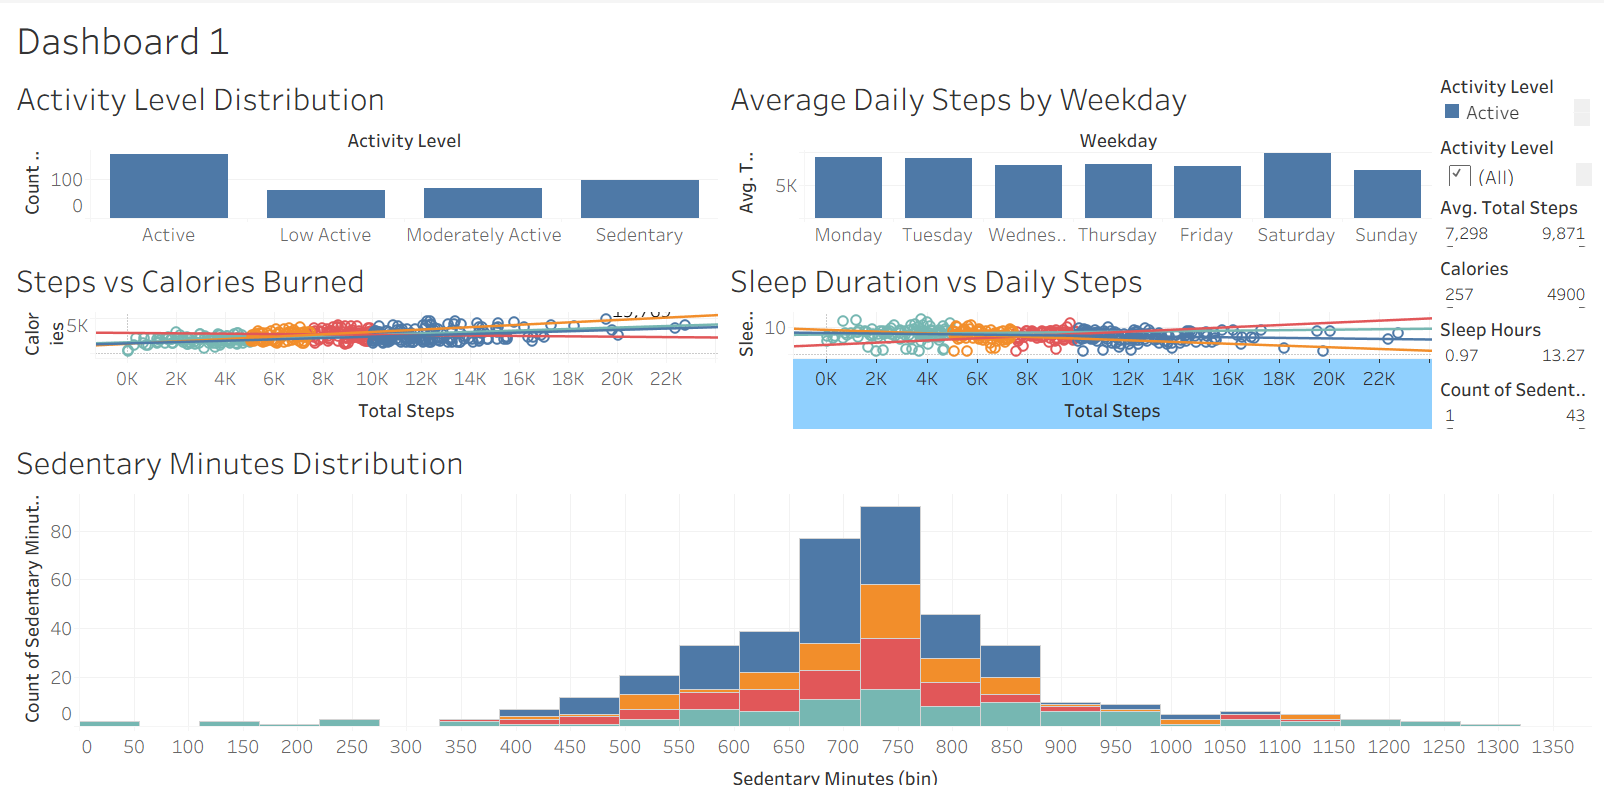

*Figure 1: Tableau dashboard showing activity, sleep and wellness trends from Fitbit data.*

### 10.0 Key Findings 

The analysis of Fitbit activity and sleep data identified several important patterns related to movement, sleep behavior and overall wellness trends.

#### 10.1 Moderate Daily Activity Levels 

The average number of daily steps recorded was approximately 8,515 steps, which is close to the commonly referenced goal of 10,000 steps but remains slightly below the recommended target. This suggests that activity levels are generally moderate, although there is still room for improvement in daily movement habits.

#### 10.2 High Sedentary Behavior 

Sedentary time emerged as one of the most significant findings in the analysis. Observations recorded an average of approximately 712 sedentary minutes per day, equivalent to nearly 12 hours of inactivity. This indicates prolonged periods of inactive behavior despite moderate activity levels being observed in other metrics. 

#### 10.3 Sleep Duration Generally Aligns with Recommendation 

Average sleep duration was approximately 6.99 hours per night, which is relatively close to the recommended 7-8 hours of sleep for adults. However, the large variation in sleep duration across observations suggests that sleeping habits are inconsistent among individuals.

#### 10.4 Physical Activity Increases Calorie Expenditure

The relationship between daily steps and calories burned demonstrated a clear positive pattern. Higher movement levels consistently corresponded with increased calorie expenditure, suggesting that increasing physical activity contributes directly to greater energy usage. 

#### 10.5 Weak RElationship Between Sleep and Physical Activity

The correlation between sleep duration and total steps was approximately -0.19, indicating a weak negative relationship. This suggests that daily movement levels alone do not strongly influence sleeping behavior and that additional factors may contribute to sleep patterns. 


#### 10.6 Activity Patterns Vary Across the Week

Daily activity trends showed variation across weekdays. Higher average step counts were observed during weekends and early weekdays, while lower movement levels appeared on selected days such as Sunday and Friday. This suggests that activity behavior changes according to weekly routines.

#### 10.7 Activity Distribution Remains Uneven

Although the Active category represented the largest portion of observations, a considerable proportion remained within Sedentary and Low Active categories. This indicates that opportunities exist to encourage more balanced and consistent activity behavior. 


### 11.0 Recommendations

Based on the findings from Fitbit activity and sleep data analysis, several recommendations can be proposed to support Bellabeat in improving user wellness engagement and encouraging healthier behaviors. 


#### 11.1 Encourage Reduction of Sedentary Behavior

The analysis revealed high levels of sedentary activity, with observations averaging approximately 712 sedentary minutes per day. Bellabeat could introduce reminders and inactivity alerts that encourage individuals to stand, stretch or take short walks after prolonged periods of inactivity.

Potential implementation strategies include:

- Hourly movement reminders
- Daily inactivity tracking notifications
- Progress indicators for reducing sedentary time

Reducing prolonged inactivity may contribute to healthier daily routines and improved wellness outcomes.


#### 11.2 Promote Consistent Daily Step Goals

Average daily step counts were moderately high but remained below the commonly referenced 10,000 target. Bellabeat could encourage gradual activity improvements by implementing personalized step goals rather than fixed targets for all individuals.

Potential implementation strategies include:

- Personalized daily step recommendations
- Weekly movement challenges
- Achievement badges and progress rewards

Personalized targets may improve motivation and encourage sustainable behavior changes.


#### 11.3 Improve Sleep Awareness Sleep Tracking Features

Although average sleep duration was close to recommended levels, sleep patterns showed considerable variation. Bellabeat could strengthen sleep-related features by providing better sleep monitoring and educational insights.

Potential implementation strategies include:

- Sleep quality reports
- Sleep consistency tracking
- Personalized bedtime recommendations
- Notifications encouraging healthy sleeping routines

Improving awareness of sleeping habits may help individuals establish more consistent patterns.


#### 11.4 Encourage Balanced Wellness Habits

The relationship between sleep and physical activity appeared relatively weak, indicating that wellness behaviors should not be treated independently. Bellabeat may benefit from integrating multiple wellness indicators into a single personalized experience.

Potential implementation strategies include:

- Wellness scores combining activity, sleep and inactivity metrics
- Personalized health summaries
- Goal recommendations based on multiple behavioral factors

This approach supports a more holistic understanding of health behavior.


#### 11.5 Use Behavioral Insights for Product Personalization

Activity patterns varied across weekdays, suggesting that behavior changes according to routine and lifestyle factors. Bellabeat could use these patterns to deliver context-based recommendations at appropriate times.

Potential implementation strategies include:

- Weekend fitness challenges
- Mid-week activity reminders
- Personalized notifications based on behavioral trends

Delivering recommendations at relevant moments may improve engagement and increase long-term product usage.

### 12.0 Conclusion

This case study analyzed Fitbit activity and sleep data to identify behavioral patterns and generate insights that support Bellabeat's business objectives. The analysis process involved data cleaning, processing, exploratory data analysis, visualizations and dashboard development to better understand relationships between physical activity, sleep and sedentary behavior.

The findings revealed that overall activity levels were moderate, with average daily steps approaching recommended targets. However, prolonged sedentary behavior emerged as a significant concern, as many observations recorded extensive periods of inactivity throughout the day. Sleep duration generally aligned with recommended levels, although substantial variation suggested inconsistent sleeping habits across observations.

The analysis also showed a positive relationship between physical activity and calorie expenditure, indicating that increased movement contributes directly to higher energy usage. In contrast, the relationship between sleep duration and activity levels appeared relatively weak, suggesting that wellness behaviors are influenced by multiple factors rather than a single variable.

Based on these findings, several recommendations were proposed for Bellabeat, including sedentary behavior through movement reminders, encouraging personalized activity goals, improving sleep awareness features and providing more personalized wellness experiences. These strategies may support stronger engagement and healthier lifestyle behaviors.

Overall, the case study demonstrates how data analytics can transform raw health data into meaningful insights that support business decision-making and improve wellness-focused products and services. 

### 13.0 Limitations and Future Improvements

Although this analysis provided useful insights into activity and wellness patterns, several limitations should be considered when interpreting the results.


#### 13.1 Dataset Size and Time Period

The Fitbit dataset represents a limited number of observations collected over a relatively short period. Behavioral patterns may vary over longer durations or across larger populations. Therefore, the findings may not fully represent broader wellness trends.

Future Improvement:

- Use larger datasets covering longer time periods
- Include more participants to improve representativeness
- Analyze seasonal or long-term behavioral changes


#### 13.2 Limited Participant Information

The dataset does not include demographic or personal characteristics such as age, gender, occupation or health status. These factors can influence activity levels, sleep behavior and calorie expenditure.

Future Improvement:

- Incorporate demographic information where appropriate
- Examine behavioral differences across population groups
- Explore whether lifestyle characteristics affect wellness patterns


#### 13.3 Sleep Measurements Focus on Duration Only

The analysis mainly evaluated total sleep duration and did not consider sleep quality indicators such as sleep stages, interruptions or consistency of sleeping patterns.

Future Improvement:

- Include additional sleep-related metrics
- Analyze sleep quality alongside sleep duration
- Explore relationships between sleep quality and activity behavior


#### 13.4 Correlation Does Not Indicate Causation

The analysis identified relationships between variables such as steps, calories and sleep duration. However, these relationships do not prove direct cause-and-effect effects.

Future Improvement:

- Apply predictive or statistical modelling techniques
- Perform regression analysis to examine influencing factors
- Investigate potential casual relationships

#### 13.5 Limited Advanced Analytics Techniques

The study focused primarily on descriptive analysis and visualization techniques. More advanced methods could provide deeper insights into wellness behavior.

Future Improvement:

- Apply clustering techniques to identify behavioral segments
- Build predictive models for activity or sleep outcomes
- Use machine learning approaches to identify hidden patterns

Overall, despite these limitations, the analysis successfully generated meaningful insights from Fitbit data and provided actionable recommendations for Bellabeat. Future enhancements may strengthen the reliability and depth of findings while supporting more informed business decisions. 